In [12]:
import zipfile

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, "r") as z:
    bad_file = z.testzip()

if bad_file is None:
    print("ZIP is valid ✅")
else:
    print("ZIP is corrupted ❌")
    print("Problem:", bad_file)

ZIP is valid ✅


In [13]:
import os

print(os.listdir("/content"))

['.config', 'archive (1).zip', 'sample_data']


In [14]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path = "/content"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [15]:
import os

print(os.listdir("/content/xray_dataset_covid19"))

['single prediction', 'test', 'train']


In [16]:
import os

train_path = "/content/xray_dataset_covid19/train"

print("Classes/Folders:")
print(os.listdir(train_path))

Classes/Folders:
['PNEUMONIA', 'NORMAL']


In [17]:
import os

train_path = "/content/xray_dataset_covid19/train"
test_path = "/content/xray_dataset_covid19/test"

for folder_path, name in [
    (train_path, "TRAIN"),
    (test_path, "TEST")
]:

    print("\n", name)

    for class_name in os.listdir(folder_path):

        class_path = os.path.join(
            folder_path,
            class_name
        )

        if os.path.isdir(class_path):

            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png")
                )
            ]

            print(
                class_name,
                ":",
                len(images),
                "images"
            )


 TRAIN
PNEUMONIA : 74 images
NORMAL : 74 images

 TEST
PNEUMONIA : 20 images
NORMAL : 20 images


In [18]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

train_dir = "/content/xray_dataset_covid19/train"
test_dir = "/content/xray_dataset_covid19/test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.20,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.20,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 148 files belonging to 2 classes.
Using 119 files for training.
Found 148 files belonging to 2 classes.
Using 29 files for validation.
Found 40 files belonging to 2 classes.


In [19]:
class_names = train_dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['NORMAL', 'PNEUMONIA']
Number of classes: 2


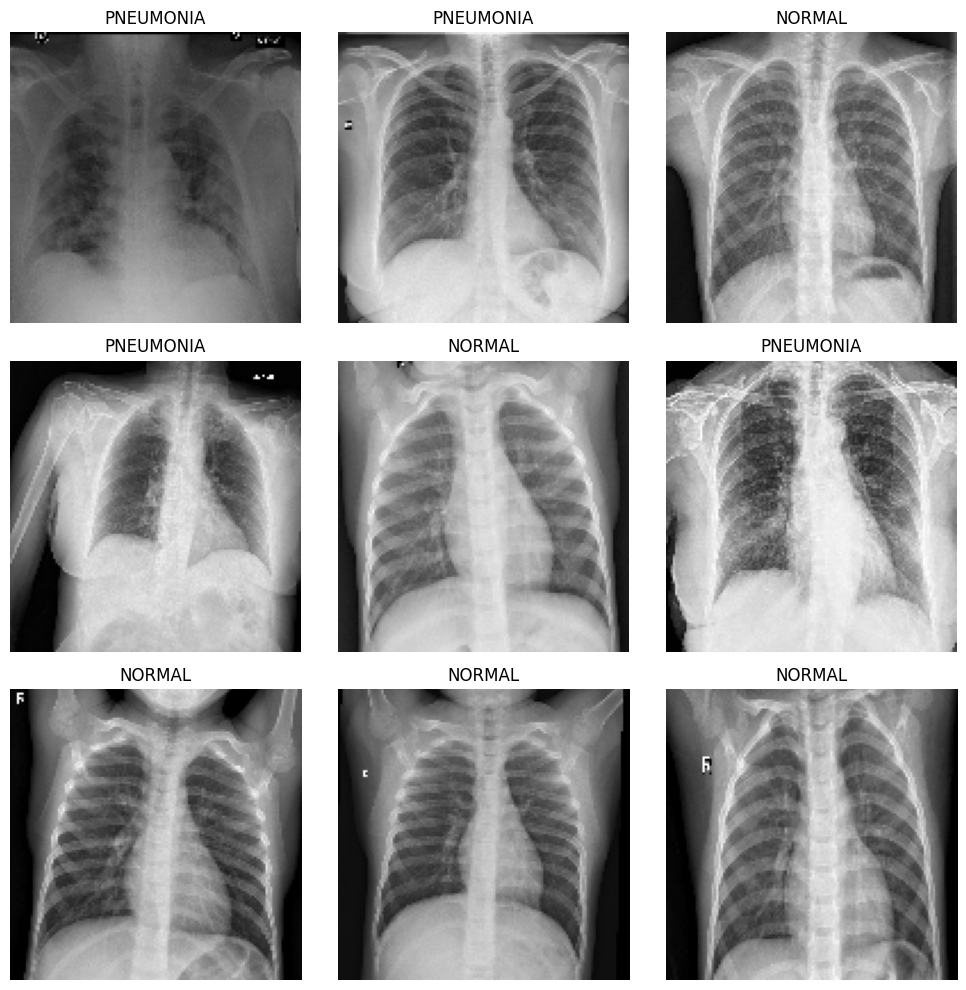

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8"),
            cmap="gray"
        )

        plt.title(
            class_names[labels[i]]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (16, 128, 128, 3)
Label batch shape: (16,)


In [22]:
import tensorflow as tf

model = tf.keras.Sequential([

    # Input image
    tf.keras.layers.Input(
        shape=(128, 128, 3)
    ),

    # Convert pixel values 0-255 → 0-1
    tf.keras.layers.Rescaling(
        1.0 / 255
    ),

    # CNN Layer 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Layer 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # CNN Layer 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert feature maps into 1D vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Reduce overfitting
    tf.keras.layers.Dropout(
        0.5
    ),

    # 2 classes: NORMAL / PNEUMONIA
    tf.keras.layers.Dense(
        2,
        activation="softmax"
    )
])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4370 - loss: 1.6049 - val_accuracy: 0.3793 - val_loss: 0.7939
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 828ms/step - accuracy: 0.6050 - loss: 0.6679 - val_accuracy: 0.8621 - val_loss: 0.6455
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 724ms/step - accuracy: 0.6134 - loss: 0.6499 - val_accuracy: 0.4828 - val_loss: 0.6214
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6975 - loss: 0.5472 - val_accuracy: 0.9310 - val_loss: 0.4202
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 986ms/step - accuracy: 0.8403 - loss: 0.4127 - val_accuracy: 0.9310 - val_loss: 0.2802
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 776ms/step - accuracy: 0.8992 - loss: 0.2725 - val_accuracy: 0.7931 - val_loss: 0.3055
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8739 - loss: 0.3361 - val_accuracy: 0.9655 - val_loss: 0.1850
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 846ms/step - accuracy: 0.9244 - loss: 0.2644 - val_accuracy: 0.9655 - val_loss: 0.179

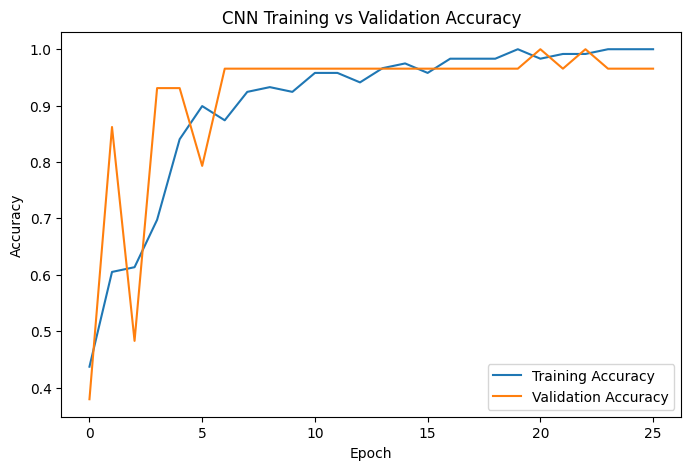

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("CNN Training vs Validation Accuracy")

plt.legend()

plt.show()

In [27]:
test_loss, test_accuracy = model.evaluate(
    test_dataset
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 1.0000 - loss: 0.0153
Test Loss: 0.015294541604816914
Test Accuracy: 1.0
Test Accuracy (%): 100.0


In [28]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", y_true)
print("Predicted labels:", y_pred)

Actual labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]
Predicted labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]


In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[20  0]
 [ 0 20]]


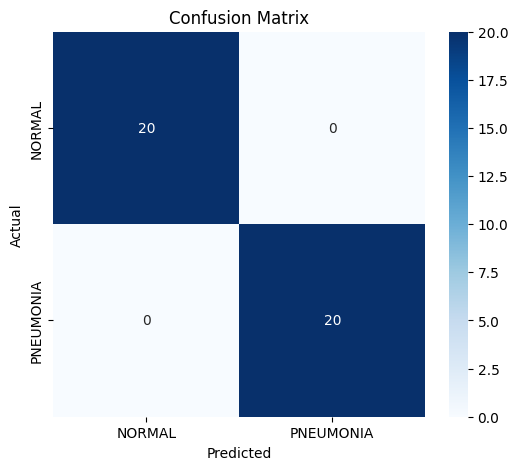

In [30]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        20
   PNEUMONIA       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [32]:
print(cm)

[[20  0]
 [ 0 20]]


In [33]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      NORMAL       1.00      1.00      1.00        20
   PNEUMONIA       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [34]:
import os

single_prediction_dir = "/content/xray_dataset_covid19/single prediction"

files = os.listdir(single_prediction_dir)

print("Files:")
for file in files:
    print(file)

Files:
normal_or_pneumonia2.jpeg
normal_or_pneumonia1.jpeg
normal_or_pneumonia3.jpeg


In [35]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

single_prediction_dir = "/content/xray_dataset_covid19/single prediction"

image_path = os.path.join(
    single_prediction_dir,
    "normal_or_pneumonia1.jpeg"
)

# Load image
image = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)

# Convert image to array
image_array = tf.keras.utils.img_to_array(image)

# Add batch dimension
image_array = tf.expand_dims(
    image_array,
    axis=0
)

# Prediction
prediction = model.predict(
    image_array,
    verbose=0
)

# Get predicted class
predicted_index = np.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index]

print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence * 100:.2f}%")

Predicted Class: NORMAL
Confidence: 99.77%


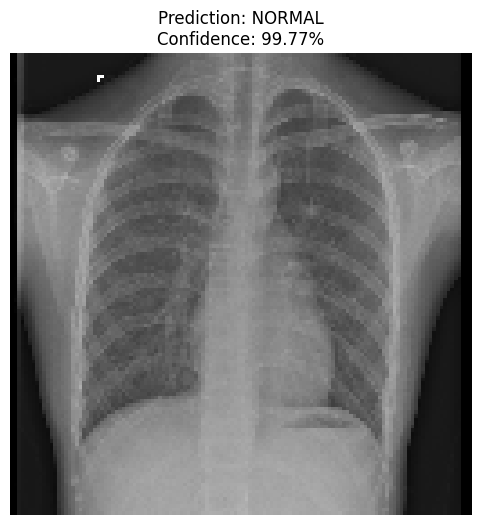

In [36]:
plt.figure(figsize=(6, 6))

plt.imshow(image, cmap="gray")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

In [37]:
for i, class_name in enumerate(class_names):
    print(
        class_name,
        ":",
        f"{prediction[0][i] * 100:.2f}%"
    )

NORMAL : 99.77%
PNEUMONIA : 0.23%
